# Phase 1 — Exploratory Data Analysis (EDA)

**Dataset:** Student Performance (UCI) — `student-mat.csv`  
**Mục tiêu:**
- Hiểu cấu trúc, kiểu dữ liệu và phân phối của 33 biến
- Phân tích biến mục tiêu `G3` (điểm cuối kỳ)
- Phát hiện missing values và outliers
- Visualize các mối quan hệ giữa biến độc lập và `G3`
- Xuất `student_mat_clean.csv` cho các phase tiếp theo

---
> **Output của notebook này:**  
> `data/processed/student_mat_clean.csv`  
> `report/figures/eda_*.png`


## 0. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
import os

warnings.filterwarnings("ignore")

# ── Hằng số dùng chung toàn notebook ──
RANDOM_SEED = 42
ALPHA       = 0.05
FIGURES_DIR = "../report/figures"
DATA_OUT    = "../data/processed"

# Tạo thư mục nếu chưa có
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(DATA_OUT, exist_ok=True)

# ── Style ──
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 150, "savefig.bbox": "tight"})

print("Setup hoàn tất.")
print(f"  ALPHA       = {ALPHA}")
print(f"  FIGURES_DIR = {FIGURES_DIR}")
print(f"  DATA_OUT    = {DATA_OUT}")


Setup hoàn tất.
  ALPHA       = 0.05
  FIGURES_DIR = ../report/figures
  DATA_OUT    = ../data/processed


## 1. Load dữ liệu

Load file gốc từ `data/raw/`. Không chỉnh sửa `df_raw` sau bước này.


In [3]:
df_raw = pd.read_csv("../data/raw/student-mat.csv", sep=";")

print(f"Shape: {df_raw.shape}  →  {df_raw.shape[0]} học sinh, {df_raw.shape[1]} biến")
print()
print("5 dòng đầu:")
df_raw.head()


Shape: (395, 33)  →  395 học sinh, 33 biến

5 dòng đầu:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 2. Tổng quan dữ liệu

### 2.1 Kiểu dữ liệu và phân loại biến

Dataset có 2 loại biến chính:
- **Numeric (int):** điểm số, tuổi, số lần vắng mặt...
- **Categorical (object):** giới tính, khu vực, trường...

Một số biến numeric thực chất là **ordinal** (Medu, Fedu, studytime, Dalc, Walc...) — cần lưu ý khi chọn test thống kê.


In [5]:
# Phân loại biến theo dtype
numeric_cols     = df_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_raw.select_dtypes(include=["object"]).columns.tolist()

# Phân loại chi tiết hơn dựa trên data dictionary
binary_cols  = ["school", "sex", "address", "famsize", "Pstatus",
                "schoolsup", "famsup", "paid", "activities",
                "nursery", "higher", "internet", "romantic"]

# Nominal: có nhiều category, KHÔNG có thứ tự — dùng Cramér's V, ANOVA/Kruskal
nominal_cols = ["Mjob", "Fjob", "reason", "guardian"]

# Ordinal: numeric nhưng có thứ tự ý nghĩa — dùng Spearman, Kruskal-Wallis
ordinal_cols = ["Medu", "Fedu", "traveltime", "studytime",
                "failures", "famrel", "freetime", "goout",
                "Dalc", "Walc", "health"]

print(f"Tổng số biến        : {df_raw.shape[1]}")
print(f"  Numeric (liên tục): {[c for c in numeric_cols if c not in ordinal_cols]}")
print(f"  Ordinal           : {ordinal_cols}")
print(f"  Binary categorical: {binary_cols}")
print(f"  Nominal categorical (không thứ tự): {nominal_cols}")
print()
print("Lưu ý: Mjob, Fjob, reason, guardian là NOMINAL")
print("       → không dùng Spearman, dùng Kruskal-Wallis hoặc ANOVA để so sánh với G3")


Tổng số biến        : 33
  Numeric (liên tục): ['age', 'absences', 'G1', 'G2', 'G3']
  Ordinal           : ['Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']
  Binary categorical: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
  Nominal categorical (không thứ tự): ['Mjob', 'Fjob', 'reason', 'guardian']

Lưu ý: Mjob, Fjob, reason, guardian là NOMINAL
       → không dùng Spearman, dùng Kruskal-Wallis hoặc ANOVA để so sánh với G3


In [6]:
# Thông tin tổng quát
df_raw.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

### 2.2 Data dictionary nhanh

| Nhóm | Biến | Loại | Mô tả |
|---|---|---|---|
| **Nhân khẩu học** | `school`, `sex`, `age`, `address` | binary/numeric | Trường, giới tính, tuổi, khu vực |
| **Gia đình** | `famsize`, `Pstatus` | binary | Quy mô gia đình, bố/mẹ sống chung hay ly thân |
| **Gia đình** | `Medu`, `Fedu` | ordinal (0–4) | Học vấn mẹ/bố: 0=không có, 1=tiểu học, 2=THCS, 3=THPT, 4=đại học+ |
| **Gia đình** | `Mjob`, `Fjob` | **nominal** | Nghề nghiệp mẹ/bố: teacher/health/services/at_home/other — **không có thứ tự** |
| **Gia đình** | `guardian` | **nominal** | Người giám hộ: mother/father/other |
| **Học tập** | `reason` | **nominal** | Lý do chọn trường: home/reputation/course/other — **không có thứ tự** |
| **Học tập** | `traveltime`, `studytime` | ordinal (1–4) | Thời gian đi học, thời gian tự học mỗi tuần |
| **Học tập** | `failures` | ordinal đặc biệt | Số lần trượt môn trước: 1/2/3, nếu ≥3 thì ghi là **4** |
| **Học tập** | `schoolsup`, `famsup`, `paid`, `higher` | binary | Hỗ trợ học tập, lớp học thêm, dự định đại học |
| **Xã hội** | `activities`, `nursery`, `internet`, `romantic` | binary | Hoạt động ngoại khóa, nhà trẻ, internet, có người yêu |
| **Xã hội** | `goout`, `Dalc`, `Walc` | ordinal (1–5) | Đi chơi, rượu ngày thường, rượu cuối tuần |
| **Sức khỏe** | `famrel`, `freetime`, `health` | ordinal (1–5) | Quan hệ gia đình, thời gian rảnh, sức khỏe tự đánh giá |
| **Sức khỏe** | `absences` | numeric (0–93) | Số buổi vắng mặt — range rộng, cần kiểm tra outlier |
| **Điểm số** | `G1`, `G2`, `G3` | numeric (0–20) | Điểm kỳ 1, kỳ 2, cuối kỳ — **G3 là biến mục tiêu** |

> **Lưu ý quan trọng:**  
> - `Mjob`, `Fjob`, `reason`, `guardian` là **nominal** — không dùng Spearman hay so sánh mean trực tiếp, dùng ANOVA hoặc Kruskal-Wallis  
> - `failures`: giá trị 4 nghĩa là "3 lần trở lên", không phải đúng 4 lần — cần note khi diễn giải


## 3. Missing values & Duplicates

Kiểm tra trước khi làm bất cứ điều gì khác — missing values ảnh hưởng đến mọi bước phân tích tiếp theo.


In [7]:
# Missing values
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({"count": missing, "pct": missing_pct})
missing_df = missing_df[missing_df["count"] > 0]

if missing_df.empty:
    print("Không có missing values.")
else:
    print("Biến có missing values:")
    print(missing_df)

# Duplicates
n_dup = df_raw.duplicated().sum()
print(f"\nSố dòng trùng lặp: {n_dup}")


Không có missing values.

Số dòng trùng lặp: 0


> **Nhận xét:** _(điền sau khi chạy)_  
> Dataset Student Performance thường không có missing values.


## 4. Thống kê mô tả

### 4.1 Biến numeric


In [8]:
desc_numeric = df_raw[numeric_cols].describe().T
desc_numeric["skewness"] = df_raw[numeric_cols].skew().round(3)
desc_numeric["kurtosis"] = df_raw[numeric_cols].kurt().round(3)
desc_numeric.round(2)


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
age,395.0,16.70,1.28,15.0,16.0,17.0,18.0,22.0,0.47,-0.00
Medu,395.0,2.75,1.09,0.0,2.0,3.0,4.0,4.0,-0.32,-1.09
Fedu,395.0,2.52,1.09,0.0,2.0,2.0,3.0,4.0,-0.03,-1.20
traveltime,395.0,1.45,0.70,1.0,1.0,1.0,2.0,4.0,1.61,2.34
studytime,395.0,2.04,0.84,1.0,1.0,2.0,2.0,4.0,0.63,-0.01
failures,395.0,0.33,0.74,0.0,0.0,0.0,0.0,3.0,2.39,5.00
famrel,395.0,3.94,0.90,1.0,4.0,4.0,5.0,5.0,-0.95,1.14
freetime,395.0,3.24,1.00,1.0,3.0,3.0,4.0,5.0,-0.16,-0.30
goout,395.0,3.11,1.11,1.0,2.0,3.0,4.0,5.0,0.12,-0.77
Dalc,395.0,1.48,0.89,1.0,1.0,1.0,2.0,5.0,2.19,4.76


### 4.2 Biến categorical — value counts


In [9]:
for col in categorical_cols:
    print(f"── {col} ──")
    vc = df_raw[col].value_counts()
    pct = (vc / len(df_raw) * 100).round(1)
    print(pd.DataFrame({"count": vc, "pct%": pct}))
    print()


── school ──
        count  pct%
school             
GP        349  88.4
MS         46  11.6

── sex ──
     count  pct%
sex             
F      208  52.7
M      187  47.3

── address ──
         count  pct%
address             
U          307  77.7
R           88  22.3

── famsize ──
         count  pct%
famsize             
GT3        281  71.1
LE3        114  28.9

── Pstatus ──
         count  pct%
Pstatus             
T          354  89.6
A           41  10.4

── Mjob ──
          count  pct%
Mjob                 
other       141  35.7
services    103  26.1
at_home      59  14.9
teacher      58  14.7
health       34   8.6

── Fjob ──
          count  pct%
Fjob                 
other       217  54.9
services    111  28.1
teacher      29   7.3
at_home      20   5.1
health       18   4.6

── reason ──
            count  pct%
reason                 
course        145  36.7
home          109  27.6
reputation    105  26.6
other          36   9.1

── guardian ──
          count  pct%
gua

## 5. Phân tích biến mục tiêu G3

`G3` là điểm cuối kỳ, thang 0–20. Hiểu phân phối của G3 trước khi chạy bất kỳ test nào vì:
- Nhiều test (t-test, ANOVA) giả định G3 xấp xỉ normal
- Phân phối lệch hoặc bimodal có thể ảnh hưởng cách diễn giải


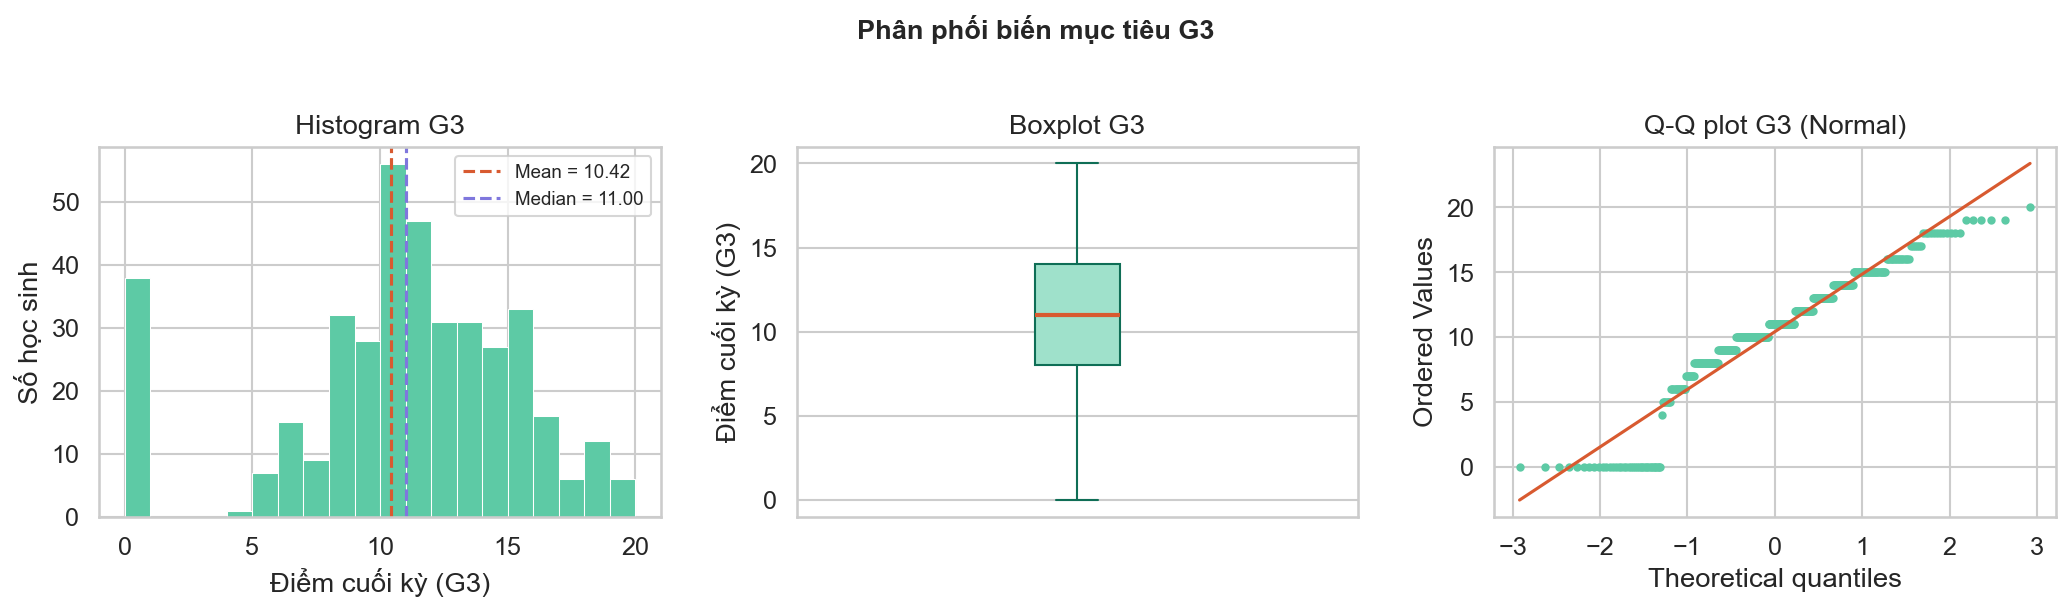

Đã lưu: eda_g3_distribution.png


In [10]:
g3 = df_raw["G3"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Histogram
axes[0].hist(g3, bins=20, color="#5DCAA5", edgecolor="white", linewidth=0.5)
axes[0].axvline(g3.mean(), color="#D85A30", linestyle="--", linewidth=1.5, label=f"Mean = {g3.mean():.2f}")
axes[0].axvline(g3.median(), color="#7F77DD", linestyle="--", linewidth=1.5, label=f"Median = {g3.median():.2f}")
axes[0].set_title("Histogram G3")
axes[0].set_xlabel("Điểm cuối kỳ (G3)")
axes[0].set_ylabel("Số học sinh")
axes[0].legend(fontsize=9)

# Boxplot
axes[1].boxplot(g3, patch_artist=True,
                boxprops=dict(facecolor="#9FE1CB", color="#0F6E56"),
                medianprops=dict(color="#D85A30", linewidth=2),
                whiskerprops=dict(color="#0F6E56"),
                capprops=dict(color="#0F6E56"),
                flierprops=dict(marker="o", color="#888780", markersize=4))
axes[1].set_title("Boxplot G3")
axes[1].set_ylabel("Điểm cuối kỳ (G3)")
axes[1].set_xticks([])

# Q-Q plot
stats.probplot(g3, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot G3 (Normal)")
axes[2].get_lines()[0].set(color="#5DCAA5", markersize=3)
axes[2].get_lines()[1].set(color="#D85A30", linewidth=1.5)

plt.suptitle("Phân phối biến mục tiêu G3", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda_g3_distribution.png")
plt.show()
print("Đã lưu: eda_g3_distribution.png")


In [11]:
# Thống kê tóm tắt G3
print("── Thống kê mô tả G3 ──")
print(f"  Mean     : {g3.mean():.3f}")
print(f"  Median   : {g3.median():.3f}")
print(f"  Std      : {g3.std():.3f}")
print(f"  Min/Max  : {g3.min()} / {g3.max()}")
print(f"  Skewness : {g3.skew():.3f}  (0 = symmetric, >1 = right skewed)")
print(f"  Kurtosis : {g3.kurt():.3f}  (0 = normal)")
print()

# Shapiro-Wilk test for normality
stat, p = stats.shapiro(g3)
print(f"── Shapiro-Wilk normality test ──")
print(f"  W = {stat:.4f},  p = {p:.4f}")
if p > ALPHA:
    print(f"  → p > {ALPHA}: Không đủ bằng chứng bác bỏ normality (có thể dùng parametric tests)")
else:
    print(f"  → p ≤ {ALPHA}: Bác bỏ normality (cân nhắc non-parametric hoặc bootstrap)")
    print(f"  Lưu ý: với n={len(g3)}, Shapiro-Wilk rất nhạy — xem Q-Q plot để đánh giá thực tế")

# Phân phối điểm 0 (học sinh không nộp bài)
n_zero = (g3 == 0).sum()
print(f"\n── Học sinh có G3 = 0: {n_zero} ({n_zero/len(g3)*100:.1f}%) ──")
if n_zero > 0:
    print("  → Cân nhắc loại nhóm này khỏi một số phân tích (có thể là dropout, không phải học lực kém)")


── Thống kê mô tả G3 ──
  Mean     : 10.415
  Median   : 11.000
  Std      : 4.581
  Min/Max  : 0 / 20
  Skewness : -0.733  (0 = symmetric, >1 = right skewed)
  Kurtosis : 0.403  (0 = normal)

── Shapiro-Wilk normality test ──
  W = 0.9287,  p = 0.0000
  → p ≤ 0.05: Bác bỏ normality (cân nhắc non-parametric hoặc bootstrap)
  Lưu ý: với n=395, Shapiro-Wilk rất nhạy — xem Q-Q plot để đánh giá thực tế

── Học sinh có G3 = 0: 38 (9.6%) ──
  → Cân nhắc loại nhóm này khỏi một số phân tích (có thể là dropout, không phải học lực kém)


> **Nhận xét:** _(điền sau khi chạy)_
> - Phân phối G3 có dạng lệch tráikết hợp với một cụm dị biệt ở giá trị 0, Hầu hết các điểm số tập trung quanh mức từ 8 đến 16. Tuy nhiên, có một cột cao bất thường ở mức điểm 0 (chiếm gần 10% tổng số học sinh), tạo nên một phân phối không chuẩn rõ rệt.
> - Mean ≈ Median (không bằng nhau hoàn toàn) Mean < Median
> - Shapiro-Wilk: p=0.0 <= alpha, bác bỏ giả thuyết phân phối chuẩn. Quan sát biểu đồ Q-Q plot, các điểm dữ liệu không bám sát đường thẳng ở hai đầu. Đặc biệt ở phần đuôi dưới (Theoretical quantiles từ -3 đến -1.5), các điểm dữ liệu nằm ngang thành một đường phẳng tại giá trị 0. Ở phần đuôi trên, dữ liệu cũng bị phẳng lại ở mức điểm tối đa 20. Do đó, biến G3 không tuân theo phân phối chuẩn. 
> - Học sinh G3=0: Quyết định: Cần tách nhóm này ra hoặc loại bỏ khi thực hiện các phân tích tương quan/hồi quy tuyến tính. Lý do: Số lượng học sinh bị điểm 0 khá lớn (38 em, chiếm 9.6%). Trong thực tế giáo dục, điểm số 0 tròn trĩnh thường đại diện cho việc bỏ thi, bỏ học (dropout) hoặc bị đình chỉ, chứ không phản ánh đúng năng lực học tập thực tế (học lực kém) theo dải điểm tuyến tính. Việc giữ lại nhóm này sẽ làm méo mó các mô hình dự báo hoặc phân tích tương quan chuẩn. Do đó, nên tách riêng nhóm này để phân tích bài toán "học sinh bỏ học" và loại họ ra khi phân tích "xu hướng học lực".


## 6. Phân tích Outlier

Dùng IQR method cho các biến numeric liên tục. Với biến ordinal (thang điểm cố định) không áp dụng outlier detection.


In [12]:
# Biến numeric thực sự liên tục (không phải thang điểm cố định)
continuous_cols = ["age", "absences", "G1", "G2", "G3"]

outlier_summary = []
for col in continuous_cols:
    Q1 = df_raw[col].quantile(0.25)
    Q3 = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_raw[col] < lower) | (df_raw[col] > upper)).sum()
    outlier_summary.append({
        "biến": col, "Q1": Q1, "Q3": Q3, "IQR": IQR,
        "lower_fence": round(lower, 2), "upper_fence": round(upper, 2),
        "n_outliers": n_out, "pct%": round(n_out / len(df_raw) * 100, 1)
    })

pd.DataFrame(outlier_summary).set_index("biến")


,Q1,Q3,IQR,lower_fence,upper_fence,n_outliers,pct%
biến,,,,,,,
age,16.0,18.0,2.0,13.0,21.0,1,0.3
absences,0.0,8.0,8.0,-12.0,20.0,15,3.8
G1,8.0,13.0,5.0,0.5,20.5,0,0.0
G2,9.0,13.0,4.0,3.0,19.0,13,3.3
G3,8.0,14.0,6.0,-1.0,23.0,0,0.0


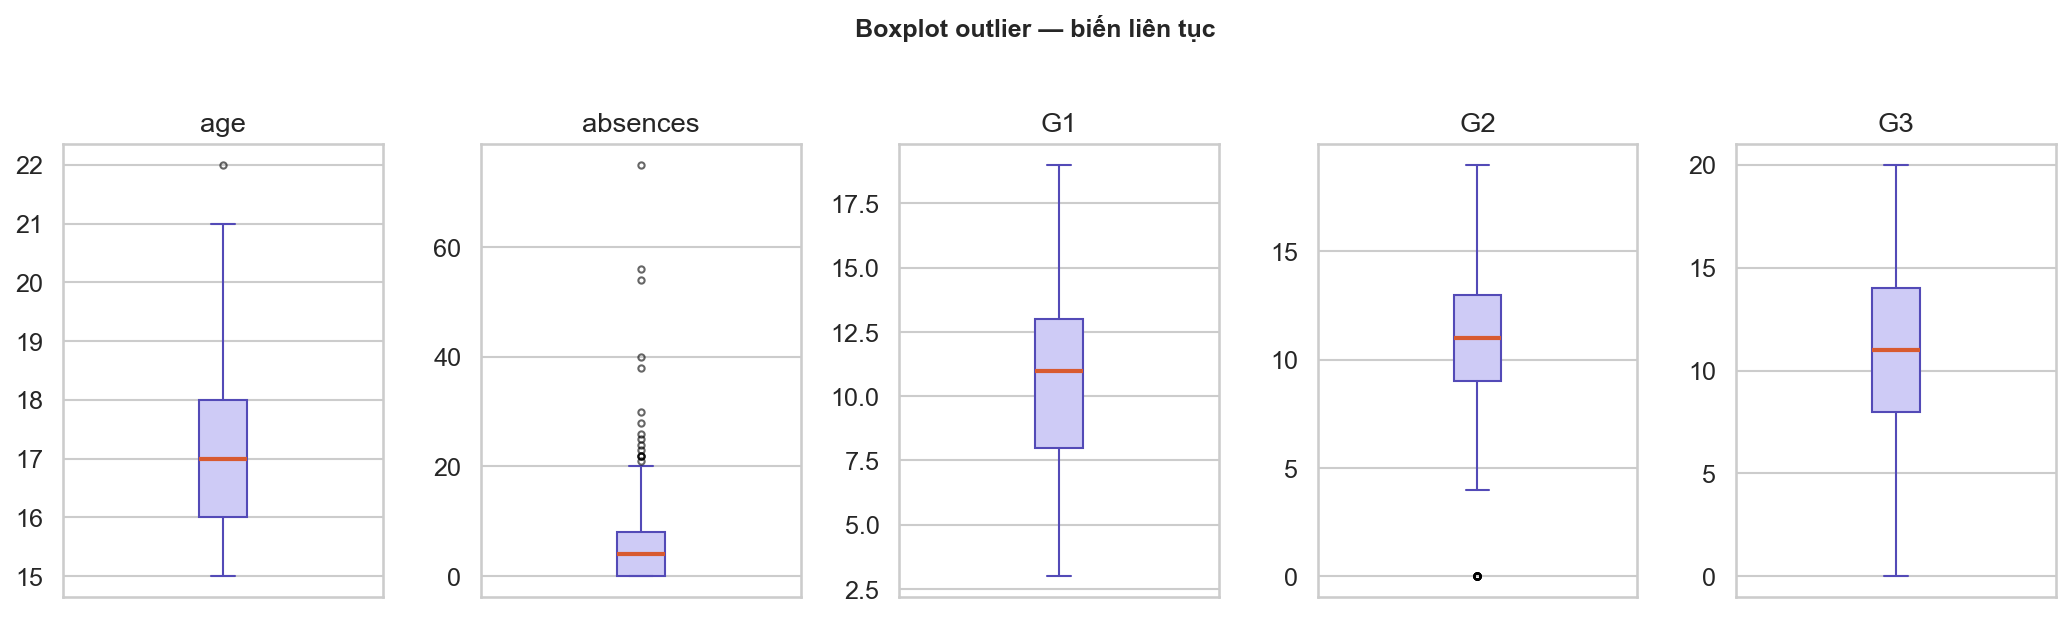

Đã lưu: eda_outliers_boxplot.png


In [13]:
# Boxplot outlier cho các biến liên tục
fig, axes = plt.subplots(1, len(continuous_cols), figsize=(14, 4))

for ax, col in zip(axes, continuous_cols):
    ax.boxplot(df_raw[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor="#CECBF6", color="#534AB7"),
               medianprops=dict(color="#D85A30", linewidth=2),
               whiskerprops=dict(color="#534AB7"),
               capprops=dict(color="#534AB7"),
               flierprops=dict(marker="o", color="#888780", markersize=3, alpha=0.6))
    ax.set_title(col)
    ax.set_xticks([])

plt.suptitle("Boxplot outlier — biến liên tục", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda_outliers_boxplot.png")
plt.show()
print("Đã lưu: eda_outliers_boxplot.png")


> **Quyết định xử lý outlier:**
> - `absences`: 15 outliers (3.8%), max ~75 — **Winsorize tại percentile 95**
>   Lý do: extreme values có thật (không phải lỗi đo lường) nhưng ảnh hưởng
>   quá lớn đến regression ở Phase 4. Winsorize giữ lại thông tin thay vì drop.
> - `G2`: 13 outliers gần 0 — sẽ tự mất khi loại G3=0 ở Section 7 (cùng nhóm dropout)
> - `age`: 1 outlier (22 tuổi) — giữ nguyên, không đáng kể
> - `G1`, `G3`: 0 outliers theo IQR — sạch, không cần xử lý


## 7. Tạo dataset sạch

Áp dụng các quyết định xử lý từ Section 5 và 6, xuất `student_mat_clean.csv`.


In [14]:
df_clean = df_raw.copy()

# ── Xử lý học sinh G3 = 0 (dropout) ──
# Quyết định: LOẠI — nhóm này không tham gia kỳ thi, không đại diện học lực
df_clean = df_clean[df_clean["G3"] > 0].reset_index(drop=True)
print(f"Đã loại {(df_raw['G3'] == 0).sum()} học sinh có G3 = 0")
print(f"  → Còn lại {len(df_clean)} học sinh\n")

# ── Xử lý outlier absences ──
# Quyết định: WINSORIZE tại percentile 95
# Lý do: extreme values có thật nhưng ảnh hưởng quá lớn đến regression
cap_val = df_clean["absences"].quantile(0.95)
df_clean["absences"] = df_clean["absences"].clip(upper=cap_val)
print(f"Winsorize absences tại percentile 95 = {cap_val}")
print(f"  → absences max sau winsorize: {df_clean['absences'].max()}\n")

# ── Kiểm tra lại G3 sau khi clean ──
from scipy import stats as _stats
w, p = _stats.shapiro(df_clean["G3"])
print(f"Shapiro-Wilk G3 sau clean: W={w:.4f}, p={p:.4f}")
print(f"  Mean={df_clean['G3'].mean():.3f}, Median={df_clean['G3'].median():.3f}, Skew={df_clean['G3'].skew():.3f}")

print(f"\nShape sau khi clean : {df_clean.shape}  (trước: {df_raw.shape})")

# Export
df_clean.to_csv(f"{DATA_OUT}/student_mat_clean.csv", index=False)
print(f"Đã xuất: {DATA_OUT}/student_mat_clean.csv")


Đã loại 38 học sinh có G3 = 0
  → Còn lại 357 học sinh

Winsorize absences tại percentile 95 = 20.0
  → absences max sau winsorize: 20

Shapiro-Wilk G3 sau clean: W=0.9808, p=0.0001
  Mean=11.524, Median=11.000, Skew=0.209

Shape sau khi clean : (357, 33)  (trước: (395, 33))
Đã xuất: ../data/processed/student_mat_clean.csv


## 8. Phân tích G3 theo nhóm

Visualize sự khác biệt G3 theo các biến categorical — đây là bước "xem trước" trực quan trước khi kiểm định chính thức ở Phase 2.


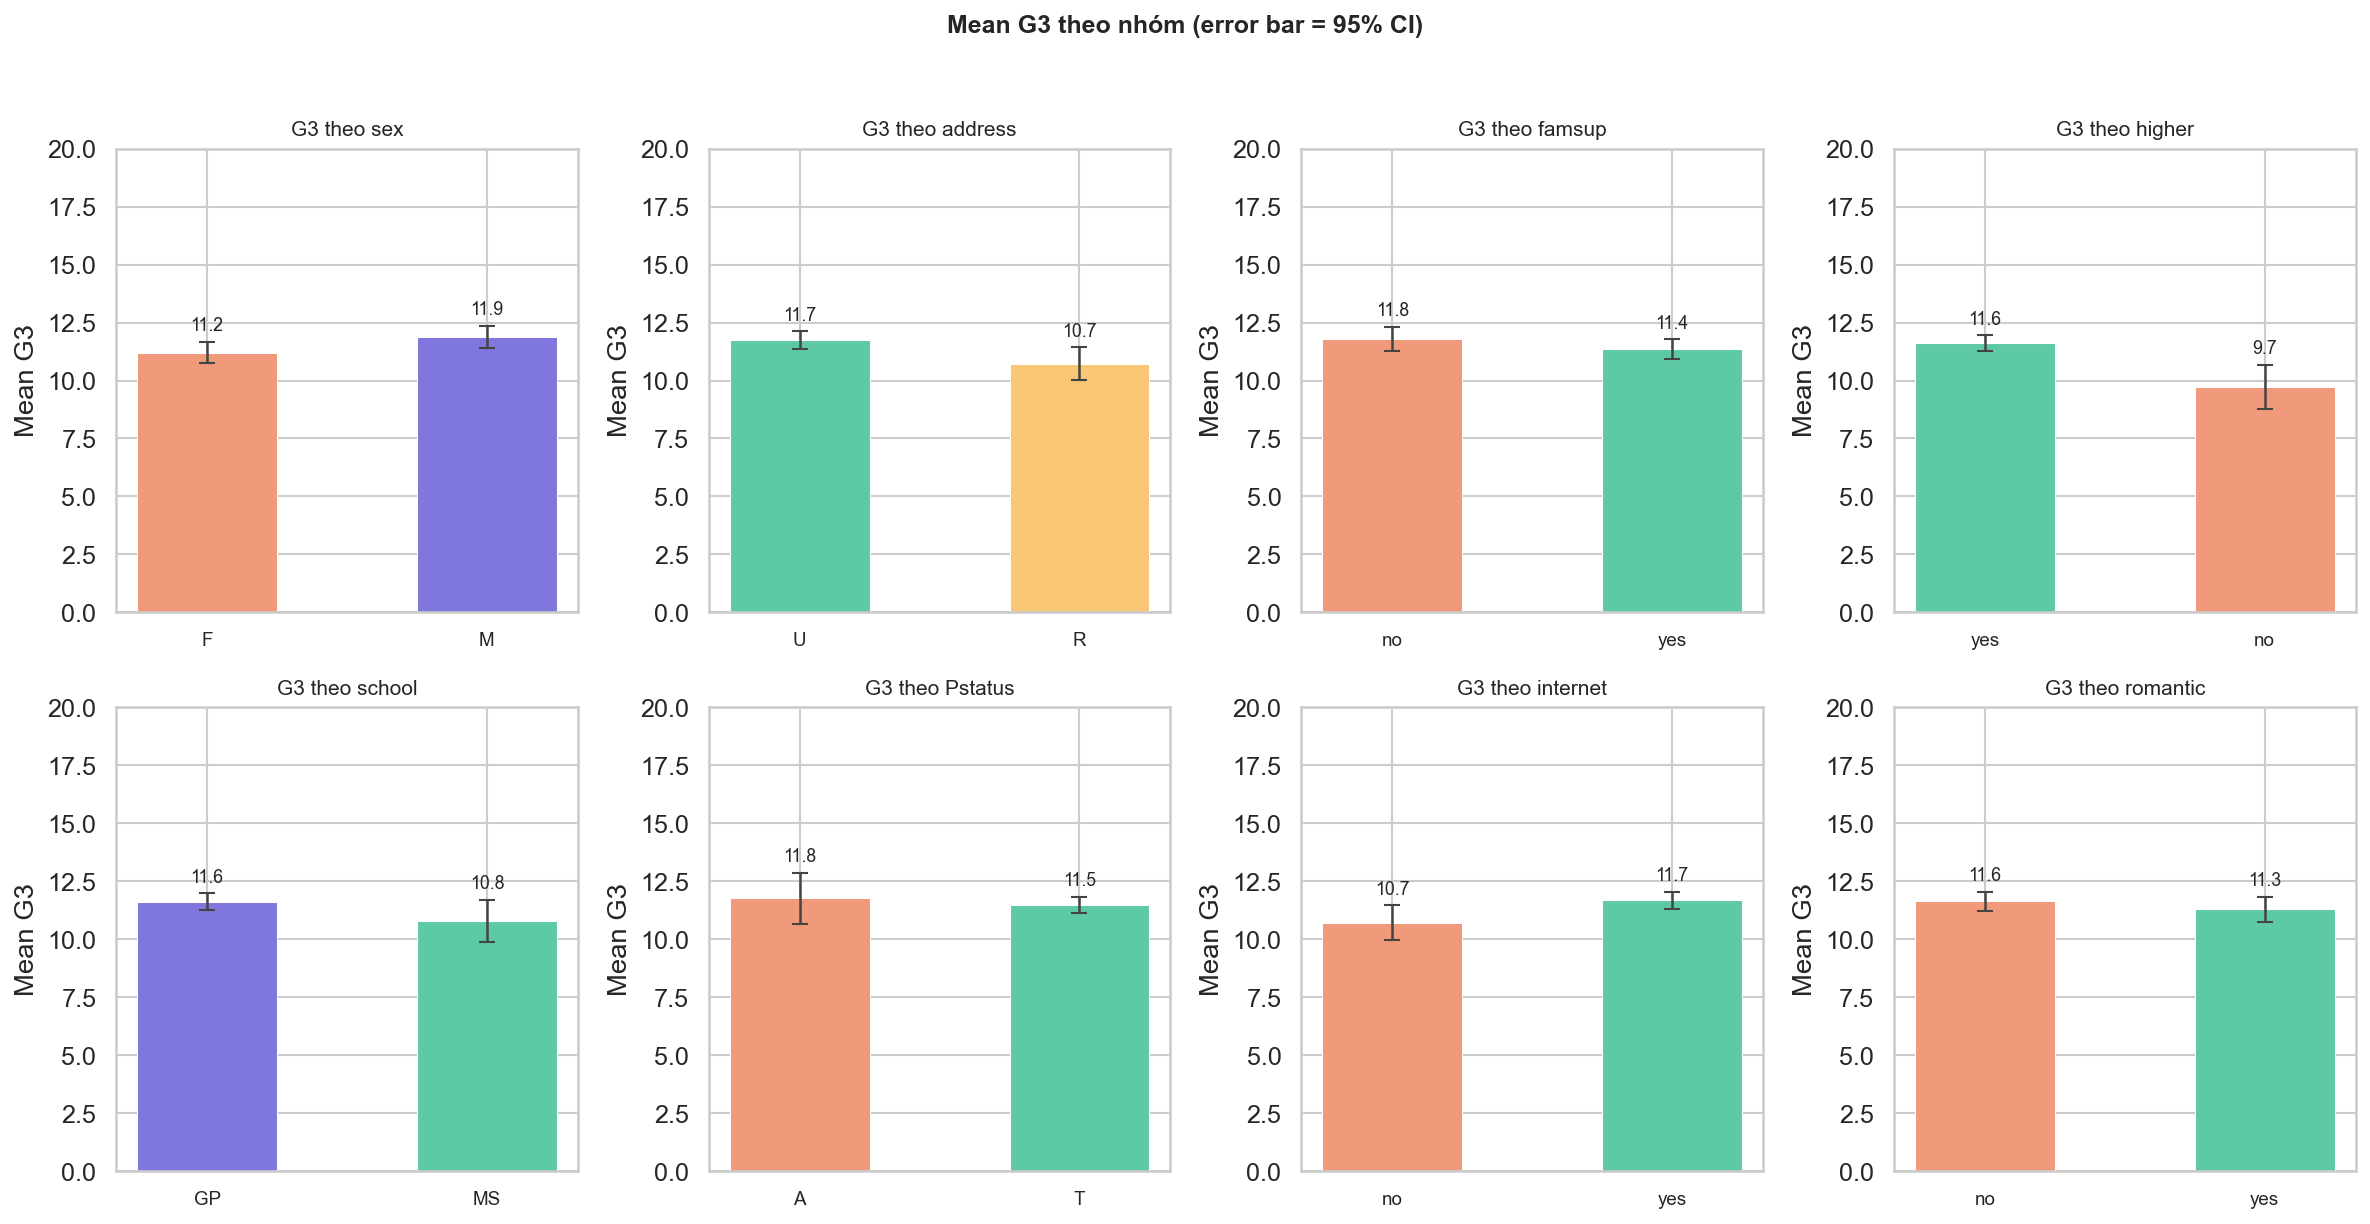

Đã lưu: eda_g3_by_group.png


In [15]:
# Các biến categorical cần so sánh với G3
group_vars = ["sex", "address", "famsup", "higher", "school", "Pstatus", "internet", "romantic"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

palette = {"yes": "#5DCAA5", "no": "#F0997B",
           "M": "#7F77DD", "F": "#F0997B",
           "U": "#5DCAA5", "R": "#FAC775",
           "GP": "#7F77DD", "MS": "#5DCAA5",
           "T": "#5DCAA5", "A": "#F0997B"}

for ax, col in zip(axes, group_vars):
    groups = df_clean[col].unique()
    group_data = [df_clean.loc[df_clean[col] == g, "G3"].values for g in groups]
    means = [d.mean() for d in group_data]

    colors = [palette.get(g, "#B4B2A9") for g in groups]
    bars = ax.bar(groups, means, color=colors, edgecolor="white", linewidth=0.5, width=0.5)

    # Thêm error bar (95% CI)
    for i, (g, d) in enumerate(zip(groups, group_data)):
        se = d.std() / np.sqrt(len(d))
        ax.errorbar(i, d.mean(), yerr=1.96*se, fmt="none",
                    color="#444441", linewidth=1.2, capsize=4)
        ax.text(i, d.mean() + 1.96*se + 0.3, f"{d.mean():.1f}",
                ha="center", va="bottom", fontsize=8.5)

    ax.set_title(f"G3 theo {col}", fontsize=10)
    ax.set_ylabel("Mean G3")
    ax.set_ylim(0, 20)
    ax.tick_params(axis="x", labelsize=9)

plt.suptitle("Mean G3 theo nhóm (error bar = 95% CI)", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda_g3_by_group.png")
plt.show()
print("Đã lưu: eda_g3_by_group.png")


> **Nhận xét sơ bộ:**
>
> **Chênh lệch rõ nhất:**
> - `higher`: yes=11.6 vs no=9.7 → chênh 1.9 điểm, lớn nhất trong tất cả các biến.
>   Error bar của "no" không overlap với "yes" → **khả năng cao significant ở Phase 2**
> - `internet`: no=10.7 vs yes=11.7 → chênh 1.0 điểm, error bar gần như không overlap
>   → **khả năng cao significant**
>
> **Chênh lệch trung bình, cần test để kết luận:**
> - `address`: U=11.7 vs R=10.7 → chênh 1.0 điểm nhưng error bar của R khá rộng
>   → **uncertain, cần t-test**
> - `school`: GP=11.6 vs MS=10.8 → chênh 0.8 điểm, error bar overlap một phần
>   → **uncertain**
> - `sex`: F=11.2 vs M=11.9 → chênh 0.7 điểm, error bar overlap rõ
>   → **khả năng thấp significant**
>
> **Overlap nhiều → khả năng không significant:**
> - `famsup`: no=11.8 vs yes=11.4 → chênh chỉ 0.4 điểm, error bar overlap hoàn toàn
>   → **khả năng cao NOT significant** — đáng ngạc nhiên so với kỳ vọng lý thuyết
> - `Pstatus`: A=11.8 vs T=11.5 → chênh 0.3 điểm, overlap hoàn toàn → **NOT significant**
> - `romantic`: no=11.6 vs yes=11.3 → chênh 0.3 điểm, overlap hoàn toàn → **NOT significant**
>
> **Lưu ý cho Phase 2:**
> `famsup` ra kết quả ngược kỳ vọng (nhóm "no" lại có mean cao hơn "yes").
> Cần kiểm tra xem có confounding variable không — ví dụ học sinh yếu mới cần
> famsup, nên nhóm "yes" tập trung học sinh có học lực thấp hơn từ đầu.
> Đây là điểm thú vị để thảo luận trong báo cáo.



## 9. Phân tích tương quan

### 9.1 Pearson/Spearman — numeric × numeric

Dùng Spearman cho các biến ordinal, Pearson cho biến liên tục thực sự.


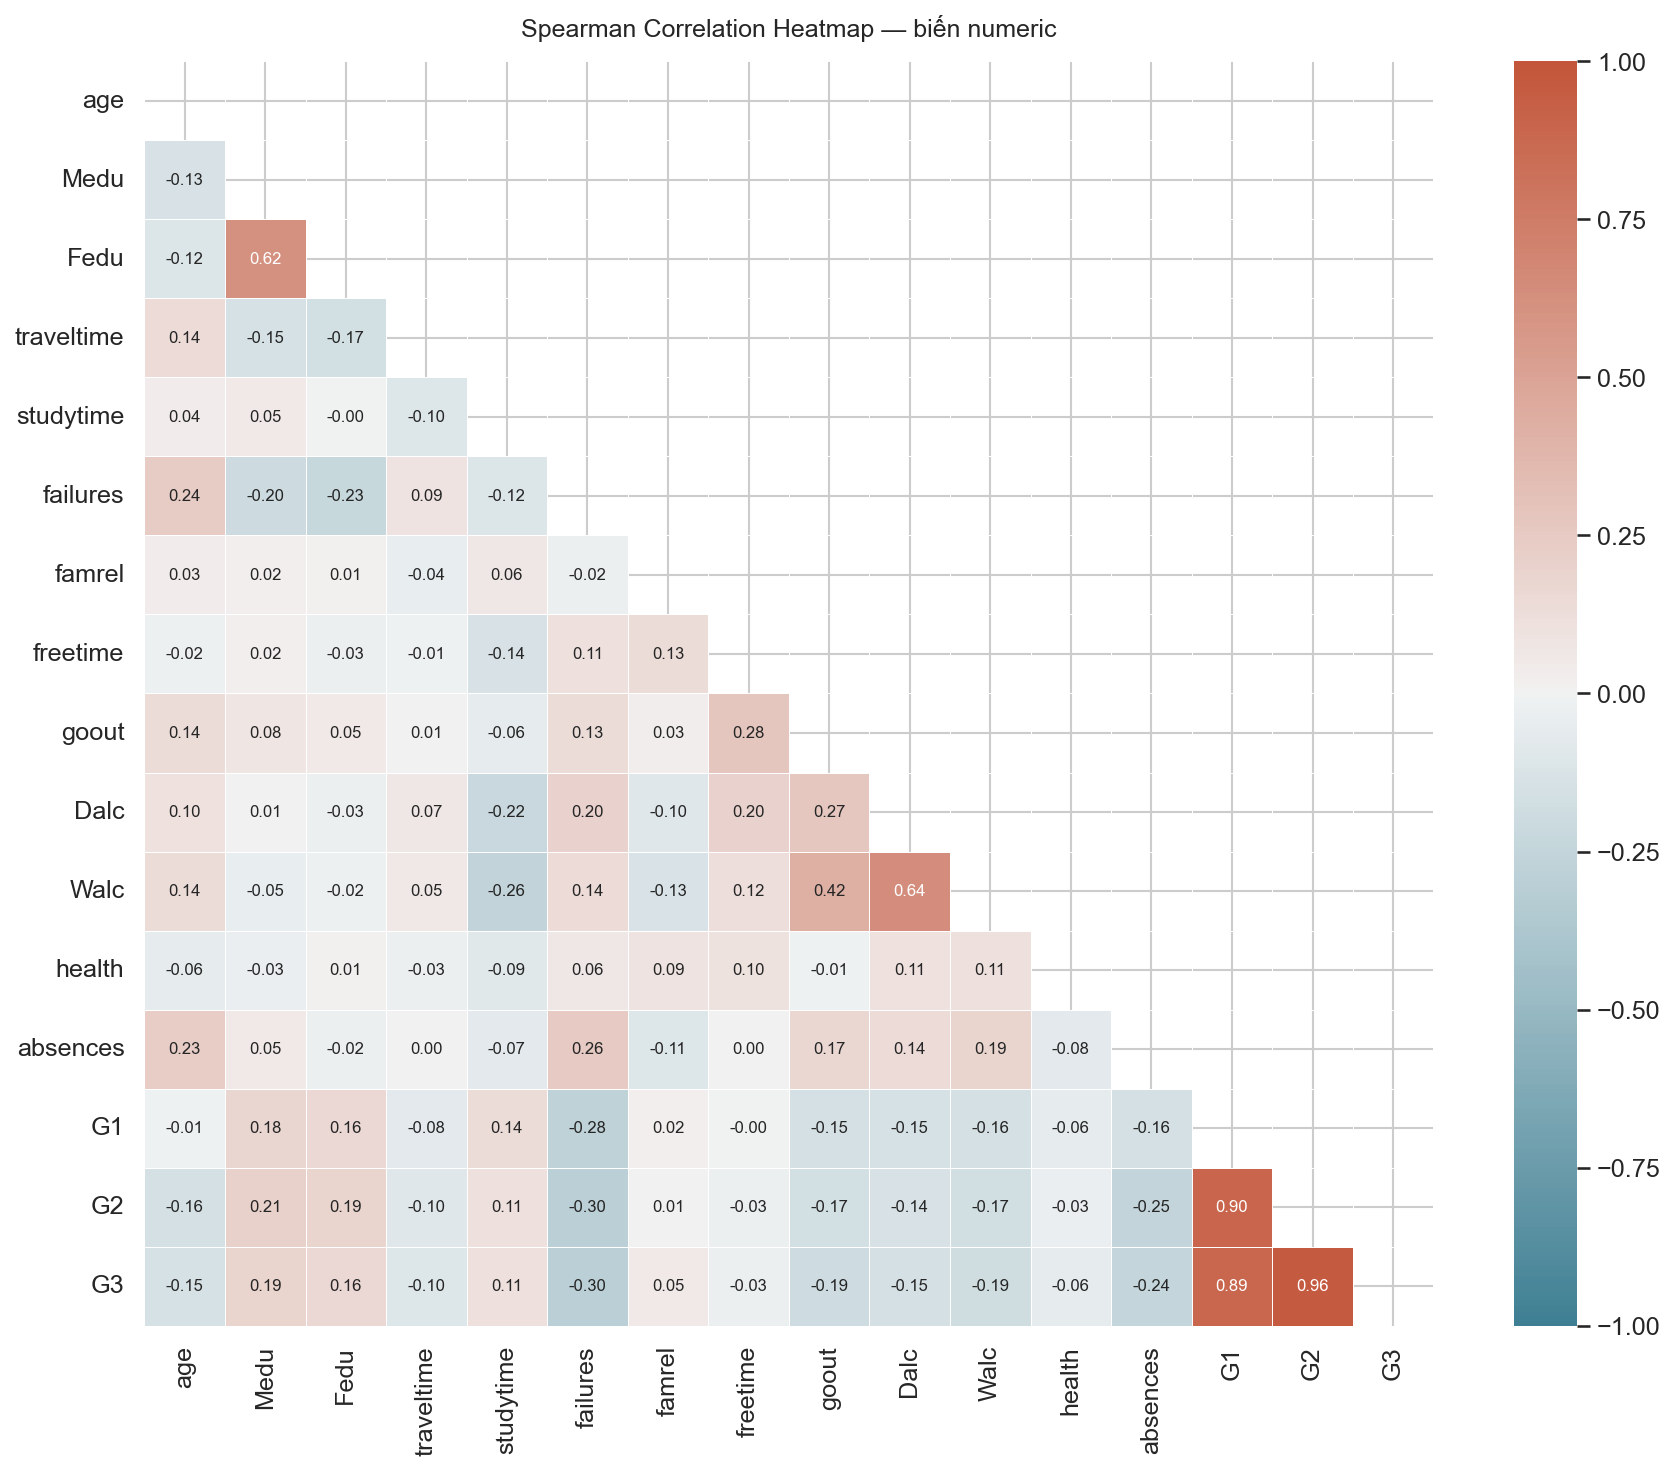

Đã lưu: eda_correlation_heatmap_spearman.png


In [16]:
# Spearman correlation matrix (robust hơn Pearson với ordinal)
corr_matrix = df_clean[numeric_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # chỉ hiển thị nửa dưới

cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap=cmap, center=0, vmin=-1, vmax=1,
            linewidths=0.3, linecolor="white",
            annot_kws={"size": 8},
            ax=ax)

ax.set_title("Spearman Correlation Heatmap — biến numeric", fontsize=12, pad=12)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda_correlation_heatmap_spearman.png")
plt.show()
print("Đã lưu: eda_correlation_heatmap_spearman.png")


In [17]:
# Top correlations với G3 (không tính G1, G2)
g3_corr = corr_matrix["G3"].drop(["G1", "G2", "G3"]).abs().sort_values(ascending=False)

print("── Top tương quan với G3 (Spearman |r|, loại trừ G1/G2) ──")
for var, r in g3_corr.items():
    direction = corr_matrix["G3"][var]
    sign = "+" if direction > 0 else "-"
    bar = "█" * int(abs(r) * 20)
    print(f"  {var:<12} {sign}{r:.3f}  {bar}")


── Top tương quan với G3 (Spearman |r|, loại trừ G1/G2) ──
  failures     -0.299  █████
  absences     -0.243  ████
  Medu         +0.192  ███
  goout        -0.188  ███
  Walc         -0.187  ███
  Fedu         +0.164  ███
  Dalc         -0.153  ███
  age          -0.148  ██
  studytime    +0.110  ██
  traveltime   -0.103  ██
  health       -0.056  █
  famrel       +0.050  
  freetime     -0.028  


> **Nhận xét:**
>
> **Tương quan mạnh nhất với G3 (ngoài G1/G2):**
> - `failures` r=-0.299 → tương quan âm mạnh nhất, đúng như kỳ vọng lý thuyết.
>   Học sinh trượt môn càng nhiều lần thì điểm cuối kỳ càng thấp.
> - `absences` r=-0.243 → vắng mặt nhiều ảnh hưởng tiêu cực rõ đến G3,
>   mạnh hơn nhiều biến hành vi khác.
> - `Medu` r=+0.192, `Fedu` r=+0.164 → học vấn bố/mẹ tương quan dương với G3,
>   confirm H8 có cơ sở. Medu mạnh hơn Fedu một chút — vai trò của mẹ
>   có thể ảnh hưởng nhiều hơn trong môi trường giáo dục này.
>
> **Các biến hành vi xã hội:**
> - `goout` r=-0.188, `Walc` r=-0.187, `Dalc` r=-0.153 → cả ba tương quan âm
>   với G3 và có độ mạnh tương đương nhau. Đặc biệt goout và Walc gần như
>   ngang nhau, gợi ý hai biến này đo cùng một "lifestyle pattern".
>   Heatmap xác nhận Walc–Dalc r=0.64, goout–Walc r=0.42 → multicollinearity
>   cần lưu ý khi đưa vào regression Phase 4.
>
> **Biến yếu, cần thận trọng khi diễn giải:**
> - `studytime` r=+0.110, `traveltime` r=-0.103 → tương quan có nhưng yếu.
> - `health` r=-0.056, `famrel` r=+0.050, `freetime` r=-0.028 → gần như
>   không tương quan với G3, không nên đưa vào hypothesis hay regression
>   trừ khi có lý thuyết rất rõ.
>
> **Phát hiện post-hoc — cân nhắc thêm vào Phase 2:**
> - `absences` r=-0.243: mạnh hơn cả `Walc` và `goout` nhưng không có
>   trong 8 hypothesis ban đầu. Đề xuất thêm H9 (post-hoc):
>   "Học sinh vắng mặt nhiều (absences cao) có G3 thấp hơn đáng kể không?"
>   → dùng Spearman correlation hoặc chia nhóm (absences=0 vs >0) rồi t-test.
>   Ghi rõ trong báo cáo đây là post-hoc hypothesis phát hiện từ EDA.
>
> **Lưu ý cho Phase 4 (Regression):**
> - Cặp Walc–Dalc (r=0.64) và cặp Medu–Fedu (r=0.62) có multicollinearity
>   cao — khi đưa vào model chỉ nên giữ một trong mỗi cặp hoặc kiểm tra VIF.
> - `goout`, `Walc`, `Dalc` đo cùng lifestyle → cân nhắc chỉ giữ `Walc`
>   (cuối tuần, ảnh hưởng học tập trực tiếp hơn) làm đại diện.

### 9.2 Cramér's V — categorical × categorical

Cramér's V đo mức độ liên kết giữa hai biến categorical (0 = không liên kết, 1 = liên kết hoàn toàn).


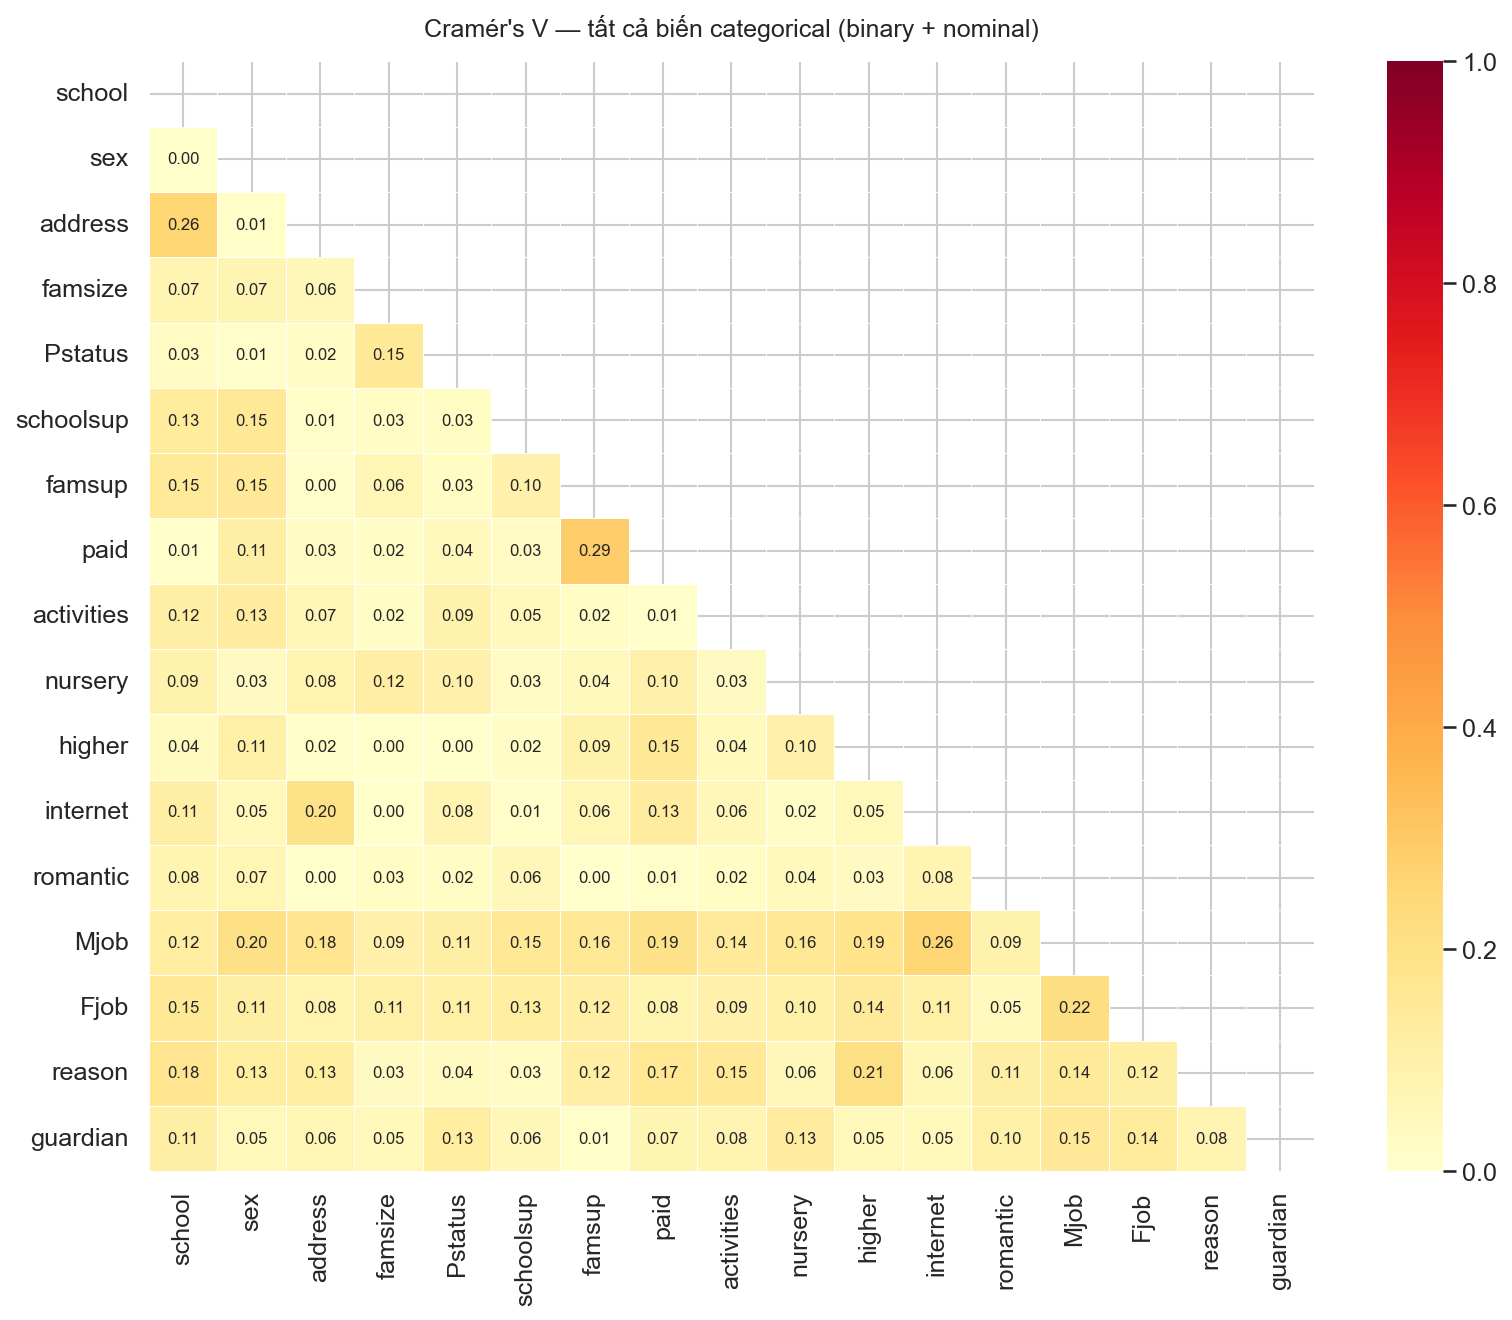

Đã lưu: eda_cramers_v_heatmap.png

── Cramér's V liên kết với 'higher' (proxy động lực học) ──
  reason       0.210  ████
  Mjob         0.186  ███
  paid         0.153  ███
  Fjob         0.143  ██
  sex          0.108  ██
  nursery      0.098  █
  famsup       0.092  █
  guardian     0.051  █
  internet     0.048  
  activities   0.045  
  school       0.038  
  romantic     0.034  
  schoolsup    0.019  
  address      0.015  
  Pstatus      0.001  
  famsize      0.000  


In [18]:
def cramers_v(x, y):
    """Tính Cramér's V cho hai biến categorical."""
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    # Guard: nếu min(r,k)-1 = 0 thì trả về 0
    if min(r, k) - 1 == 0:
        return 0.0
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# Cramér's V cho tất cả categorical (binary + nominal)
# binary_cols + nominal_cols = toàn bộ categorical
all_cat = binary_cols + nominal_cols

cv_matrix = pd.DataFrame(index=all_cat, columns=all_cat, dtype=float)
for c1 in all_cat:
    for c2 in all_cat:
        cv_matrix.loc[c1, c2] = cramers_v(df_clean[c1], df_clean[c2])

fig, ax = plt.subplots(figsize=(11, 9))
mask_cv = np.triu(np.ones_like(cv_matrix, dtype=bool))
sns.heatmap(cv_matrix.astype(float), mask=mask_cv, annot=True, fmt=".2f",
            cmap="YlOrRd", vmin=0, vmax=1,
            linewidths=0.3, linecolor="white",
            annot_kws={"size": 8},
            ax=ax)
ax.set_title("Cramér's V — tất cả biến categorical (binary + nominal)", fontsize=12, pad=12)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda_cramers_v_heatmap.png")
plt.show()
print("Đã lưu: eda_cramers_v_heatmap.png")

# Top Cramér's V với sex, address (2 biến trong hypothesis)
print("\n── Cramér's V liên kết với 'higher' (proxy động lực học) ──")
cv_higher = cv_matrix["higher"].drop("higher").sort_values(ascending=False)
for var, v in cv_higher.items():
    bar = "█" * int(v * 20)
    print(f"  {var:<12} {v:.3f}  {bar}")


### 9.3 Point-biserial correlation — binary categorical × G3

Đo tương quan giữa biến binary (yes/no) và G3.


In [19]:
binary_vars = ["schoolsup", "famsup", "paid", "activities",
               "nursery", "higher", "internet", "romantic"]

print("── Point-biserial correlation với G3 ──")
print(f"  {'Biến':<12} {'r':>7}  {'p-value':>10}  {'Kết luận'}")
print("  " + "─" * 55)

for var in binary_vars:
    # Encode yes=1, no=0
    encoded = df_clean[var].map({"yes": 1, "no": 0})
    r, p = stats.pointbiserialr(encoded, df_clean["G3"])
    sig = f"significant (α={ALPHA})" if p < ALPHA else "not significant"
    direction = "↑ G3" if r > 0 else "↓ G3"
    print(f"  {var:<12} {r:>7.3f}  {p:>10.4f}  {sig} {direction}")


── Point-biserial correlation với G3 ──
  Biến               r     p-value  Kết luận
  ───────────────────────────────────────────────────────
  schoolsup     -0.238      0.0000  significant (α=0.05) ↓ G3
  famsup        -0.067      0.2046  not significant ↓ G3
  paid          -0.029      0.5863  not significant ↓ G3
  activities     0.059      0.2695  not significant ↑ G3
  nursery        0.027      0.6172  not significant ↑ G3
  higher         0.113      0.0322  significant (α=0.05) ↑ G3
  internet       0.112      0.0350  significant (α=0.05) ↑ G3
  romantic      -0.050      0.3467  not significant ↓ G3


> **Nhận xét:**
>
> **Biến binary significant với G3:**
> - `schoolsup` r=-0.238 (p<0.001) → tương quan âm mạnh nhất trong nhóm binary,
>   ngược kỳ vọng. Tương tự `famsup` ở Section 8, học sinh yếu mới được nhà trường
>   hỗ trợ thêm — đây là **selection bias** chứ không phải schoolsup gây ra điểm thấp.
>   Cần giải thích rõ trong báo cáo, không được diễn giải nhân quả.
> - `higher` r=+0.113 (p=0.032) → significant nhưng yếu hơn kỳ vọng so với
>   biểu đồ Section 8 (mean chênh 1.9 điểm). Lý do: point-biserial đo tương quan
>   tuyến tính, trong khi chênh lệch mean lớn nhưng variance trong mỗi nhóm cũng lớn.
> - `internet` r=+0.112 (p=0.035) → significant, nhất quán với Section 8.
>   Học sinh có internet ở nhà có lợi thế tiếp cận tài liệu học tập.
>
> **Biến không significant:**
> - `famsup`, `paid`, `activities`, `nursery`, `romantic` → p > 0.05,
>   không có bằng chứng tương quan với G3. Đặc biệt `paid` (học thêm có trả tiền)
>   r=-0.029 gần như bằng 0 — hiệu quả của học thêm không thể hiện trong data này.
>
> **Cramér's V với `higher`:**
> - `reason` V=0.210 liên kết mạnh nhất với `higher` — học sinh chọn trường vì
>   "reputation" có xu hướng muốn học đại học hơn. Gợi ý `reason` có thể là
>   confounding variable khi phân tích H6.
> - `Mjob` V=0.186, `Fjob` V=0.143 → nghề nghiệp bố/mẹ liên kết với động lực
>   học đại học của con, nhất quán với H8 (Medu/Fedu → G3).
>
> **Lưu ý cho Phase 2:**
> - `schoolsup` và `famsup` đều có direction âm — cần thảo luận confounding
>   trong phần diễn giải H3, không kết luận nhân quả.
> - `internet` significant nhưng không có trong 8 hypothesis ban đầu →
>   có thể ghi nhận thêm dưới dạng post-hoc observation (không cần test riêng,
>   point-biserial này đã đủ bằng chứng).

### 9.4 Phân tích G3 theo Mjob, Fjob, reason — biến nominal

`Mjob`, `Fjob`, `reason` là **nominal** (không có thứ tự). Dùng boxplot theo nhóm và Kruskal-Wallis test để xem liệu nghề nghiệp bố/mẹ hay lý do chọn trường có liên quan G3 không.


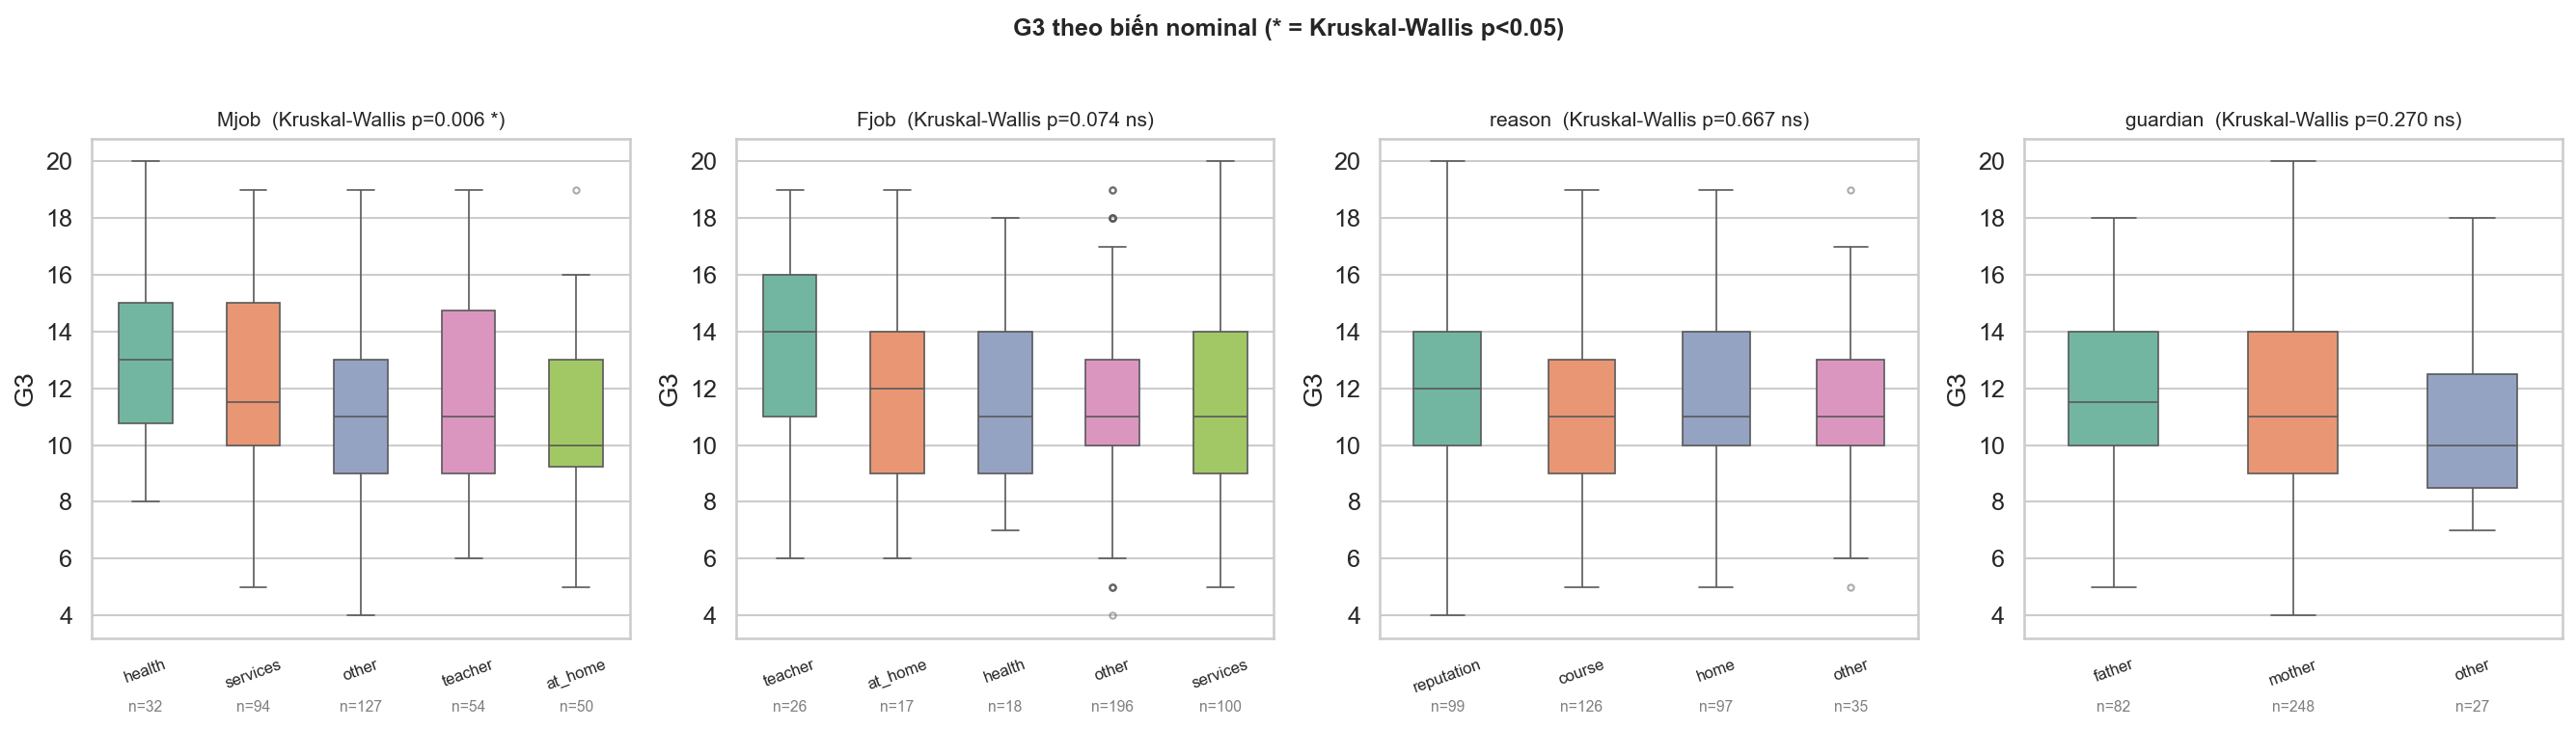

Đã lưu: eda_g3_by_nominal.png


In [20]:
nominal_g3_vars = ["Mjob", "Fjob", "reason", "guardian"]

fig, axes = plt.subplots(1, len(nominal_g3_vars), figsize=(18, 5))

for ax, var in zip(axes, nominal_g3_vars):
    order = df_clean.groupby(var)["G3"].median().sort_values(ascending=False).index

    sns.boxplot(data=df_clean, x=var, y="G3", order=order,
                palette="Set2", width=0.5, linewidth=0.8,
                flierprops=dict(marker="o", markersize=3, alpha=0.5),
                ax=ax)

    # Kruskal-Wallis test (non-parametric, phù hợp cho nominal)
    groups = [df_clean.loc[df_clean[var] == g, "G3"].values
              for g in order]
    stat, p = stats.kruskal(*groups)
    sig = "*" if p < ALPHA else "ns"
    ax.set_title(f"{var}  (Kruskal-Wallis p={p:.3f} {sig})", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("G3")
    ax.tick_params(axis="x", rotation=20, labelsize=8)

    # Thêm n trên mỗi box
    for j, g in enumerate(order):
        n = (df_clean[var] == g).sum()
        ax.text(j, 0.5, f"n={n}", ha="center", va="bottom", fontsize=7.5,
                color="gray")

plt.suptitle("G3 theo biến nominal (* = Kruskal-Wallis p<0.05)", fontsize=12,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda_g3_by_nominal.png")
plt.show()
print("Đã lưu: eda_g3_by_nominal.png")


> **Nhận xét:**
>
> **Mjob (p=0.006 ✓ significant):**
> - `health` (median~13) và `services` (median~12) cao hơn rõ so với
>   `at_home` (median~10) và `other` (median~10).
> - `teacher` (median~14.5) cao nhất nhưng n=54 khá nhỏ, box rộng.
> - Đúng như kỳ vọng: mẹ làm nghề liên quan giáo dục/y tế → con có điểm cao hơn.
> - **Ứng viên post-hoc hypothesis cho Phase 2** — ghi rõ phát hiện từ EDA.
>
> **Fjob (p=0.074 ns):**
> - Pattern tương tự Mjob nhưng không significant. `teacher` (median~14)
>   cao nhất tuy nhiên n=26 quá nhỏ → variance lớn, không đủ power để detect.
> - Kết quả nhất quán với Spearman heatmap: Medu (r=+0.19) mạnh hơn Fedu (r=+0.16)
>   → vai trò của mẹ ảnh hưởng đến G3 rõ hơn bố trong dataset này.
>
> **reason (p=0.667 ns):**
> - Không có sự khác biệt đáng kể. `reputation` và `course` có median tương đương
>   `home`. Cramér's V với `higher` cao (0.210) nhưng không translate thành
>   khác biệt G3 trực tiếp — `reason` ảnh hưởng động lực nhưng không ảnh hưởng
>   kết quả cuối kỳ một cách độc lập.
>
> **guardian (p=0.270 ns):**
> - `father` (n=82) và `mother` (n=248) tương đương nhau.
>   `other` (n=27) có median thấp hơn và IQR rộng hơn nhưng n quá nhỏ
>   để kết luận.
>
> **Liên hệ với H8 (Medu/Fedu):**
> - Mjob significant có thể phần lớn được giải thích bởi Medu vì hai biến
>   này tương quan chặt (mẹ học vấn cao → làm nghề health/teacher).
>   Trong Phase 4 regression, nếu đưa cả Mjob lẫn Medu vào model thì
>   kiểm tra VIF — nhiều khả năng một trong hai sẽ bị loại do multicollinearity.
>   Medu nên được ưu tiên giữ vì là ordinal có thể đưa thẳng vào regression,
>   còn Mjob cần dummy encoding làm model phức tạp hơn.

## 10. Scatter plots — G3 vs biến liên tục

Visualize quan hệ tuyến tính giữa G3 và các biến numeric quan trọng.


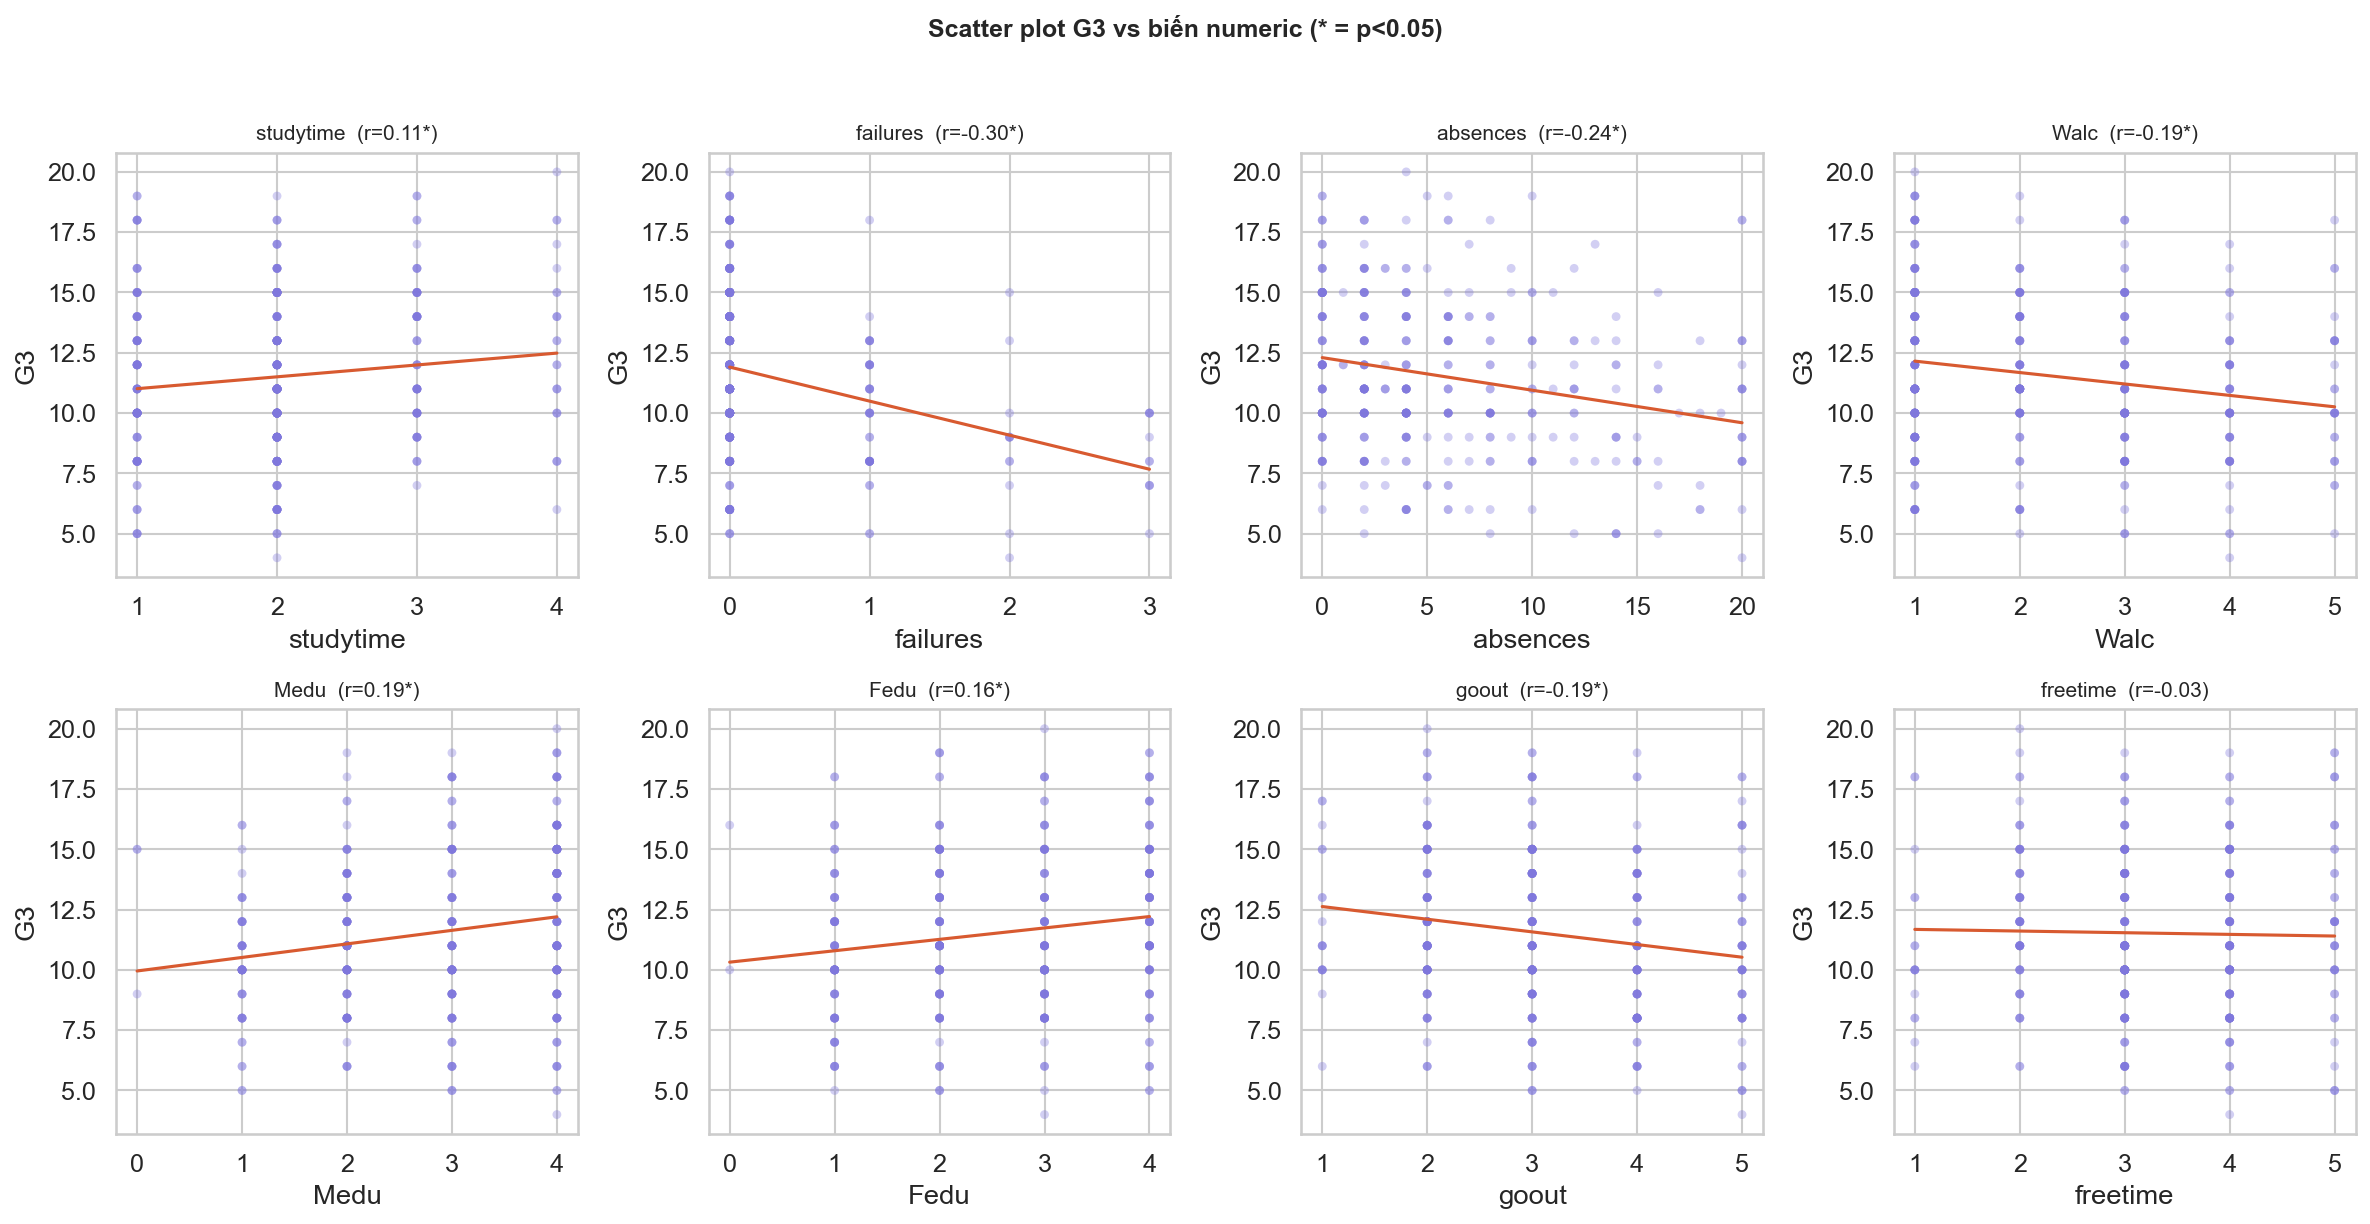

Đã lưu: eda_scatter_g3.png


In [21]:
scatter_vars = ["studytime", "failures", "absences", "Walc", "Medu", "Fedu", "goout", "freetime"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, var in zip(axes, scatter_vars):
    ax.scatter(df_clean[var], df_clean["G3"],
               alpha=0.35, s=18, color="#7F77DD", edgecolors="none")

    # Regression line
    m, b = np.polyfit(df_clean[var], df_clean["G3"], 1)
    x_line = np.linspace(df_clean[var].min(), df_clean[var].max(), 100)
    ax.plot(x_line, m * x_line + b, color="#D85A30", linewidth=1.5)

    r, p = stats.spearmanr(df_clean[var], df_clean["G3"])
    sig_star = "*" if p < ALPHA else ""
    ax.set_title(f"{var}  (r={r:.2f}{sig_star})", fontsize=10)
    ax.set_xlabel(var)
    ax.set_ylabel("G3")

plt.suptitle("Scatter plot G3 vs biến numeric (* = p<0.05)", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda_scatter_g3.png")
plt.show()
print("Đã lưu: eda_scatter_g3.png")


## 11. Tổng kết Phase 1

### Findings quan trọng

| # | Finding | Ý nghĩa cho Phase tiếp theo |
|---|---|---|
| 1 | Phân phối G3: lệch trái nhẹ (skew=-0.733), mean=10.42, median=11.00. Q-Q plot cho thấy phần core bám sát đường normal, lệch chủ yếu ở hai đuôi | Sau khi loại G3=0, có thể dùng parametric tests (t-test, ANOVA). Vẫn báo cáo non-parametric song song để robust |
| 2 | G3=0: n=38 (9.6%) — nhóm dropout không tham gia kỳ thi, tách biệt hẳn khỏi phân phối chính | Đã loại → còn 357 học sinh. Mọi Phase tiếp theo dùng dataset này |
| 3 | Tương quan mạnh nhất với G3 (ngoài G1/G2): `failures` r=-0.30 > `absences` r=-0.24 > `Medu` r=+0.19 > `goout` r=-0.19 > `Walc` r=-0.19 | `failures` và `absences` là predictors ưu tiên trong Phase 4. Cặp Walc–Dalc (r=0.64) và Medu–Fedu (r=0.62) cần kiểm tra VIF |
| 4 | Outlier `absences`: 15 outliers (3.8%), max~75, phân phối right-skewed nặng | Đã winsorize tại percentile 95. absences max sau xử lý = 20 |
| 5 | `Mjob` significant (Kruskal-Wallis p=0.006): nhóm health/teacher có G3 cao hơn at_home | Thêm vào thảo luận Phase 4 — kiểm tra VIF với Medu vì hai biến tương quan cao |
| 6 | `schoolsup` r=-0.238 và `famsup` r=-0.067: cả hai âm với G3 — ngược kỳ vọng | Confounding: học sinh yếu mới được hỗ trợ. Không diễn giải nhân quả trong Phase 2 |
| 7 | `freetime` r=-0.03, `health` r=-0.06, `famrel` r=+0.05: gần như không tương quan G3 | Không đưa vào hypothesis Phase 2. Có thể thử trong regression Phase 4 nhưng kỳ vọng không significant |
| 8 | Post-hoc: `absences` đủ mạnh để thêm vào hypothesis testing | Thêm H9 (post-hoc) vào Phase 2, ghi rõ nguồn gốc trong báo cáo |

### Quyết định xử lý data

| Vấn đề | Quyết định | Lý do |
|---|---|---|
| G3 = 0 (n=38) | **Loại** | Dropout — không đại diện học lực, làm méo phân phối và kéo mean xuống |
| Outlier absences | **Winsorize tại pct 95** | Extreme values có thật nhưng ảnh hưởng quá lớn đến regression Phase 4 |
| Outlier age=22 | **Giữ nguyên** | Chỉ 1 quan sát, không ảnh hưởng đáng kể |
| Normality G3 | **Parametric + non-parametric song song** | Sau khi loại G3=0, Q-Q plot chấp nhận được. Báo cáo cả hai để robust với n=357 |

### Lưu ý cho các Phase tiếp theo

- **Phase 2:** Ưu tiên `failures`, `absences`, `Medu/Fedu`, `higher` — có evidence mạnh từ EDA. `famsup` và `schoolsup` cần diễn giải cẩn thận (confounding). H9 (`absences`) là post-hoc, ghi rõ trong báo cáo.
- **Phase 4:** Không đưa đồng thời Walc+Dalc hoặc Medu+Fedu vào cùng một model — kiểm tra VIF. Mjob cần dummy encoding nếu muốn đưa vào, cân nhắc giữ Medu làm đại diện thay thế.
- **Phase 6:** `schoolsup` và `famsup` là ví dụ điển hình của **selection bias** — học sinh yếu được chọn vào nhóm hỗ trợ. Dùng làm case study cho phần Measurement Theory.

### Output
- `data/processed/student_mat_clean.csv` — 357 học sinh, absences đã winsorize
- `report/figures/eda_*.png` — 6 figures: distribution, outliers, group analysis, Spearman heatmap, Cramér's V, scatter plots, nominal boxplots

In [22]:
# Kiểm tra output files đã được tạo
print("── Output files ──")
for f in os.listdir(FIGURES_DIR):
    if f.startswith("eda_"):
        size = os.path.getsize(f"{FIGURES_DIR}/{f}") // 1024
        print(f"  {f}  ({size} KB)")

clean_path = f"{DATA_OUT}/student_mat_clean.csv"
if os.path.exists(clean_path):
    df_check = pd.read_csv(clean_path)
    print(f"\nstudent_mat_clean.csv: {df_check.shape[0]} rows × {df_check.shape[1]} cols ✓")


── Output files ──
  eda_correlation_heatmap_spearman.png  (167 KB)
  eda_cramers_v_heatmap.png  (165 KB)
  eda_g3_by_group.png  (82 KB)
  eda_g3_by_nominal.png  (69 KB)
  eda_g3_distribution.png  (84 KB)
  eda_outliers_boxplot.png  (43 KB)
  eda_scatter_g3.png  (205 KB)

student_mat_clean.csv: 357 rows × 33 cols ✓
